--2026-10-05 11:00:19--  https://picsum.photos/400/300
Resolving picsum.photos (picsum.photos)... 104.26.4.30, 172.67.74.163, 104.26.5.30, ...
Connecting to picsum.photos (picsum.photos)|104.26.4.30|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://fastly.picsum.photos/id/1012/400/300.jpg?hmac=o5TZ36SB16B0Tjn_eiLGKj-wynwSmiiov-jutCGl3Ww [following]
--2026-10-05 11:00:19--  https://fastly.picsum.photos/id/1012/400/300.jpg?hmac=o5TZ36SB16B0Tjn_eiLGKj-wynwSmiiov-jutCGl3Ww
Resolving fastly.picsum.photos (fastly.picsum.photos)... 151.101.1.91, 151.101.65.91, 151.101.129.91, ...
Connecting to fastly.picsum.photos (fastly.picsum.photos)|151.101.1.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29911 (29K) [image/jpeg]
Saving to: ‘image.jpg’

image.jpg           100%[===================>]  29.21K  --.-KB/s    in 0.003s  

2026-10-05 11:00:19 (9.46 MB/s) - ‘image.jpg’ saved [29911/29911]



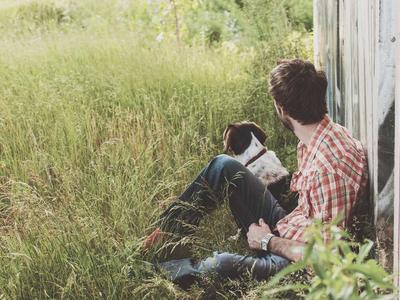

In [12]:
# TASK-2.1 READING AN IMAGE
!wget -O image.jpg "https://picsum.photos/400/300"

from PIL import Image
img = Image.open('image.jpg')
display(img)

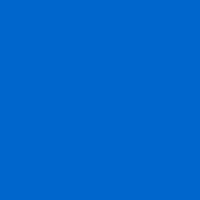

Success! Image saved as 'my_blue_square.png'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
#Task 2.2 writing an image

from PIL import Image
import numpy as np
from google.colab import files


# 1. Generate visual image data (a 200x200 pixel blue square)
# Shape: (Height=200, Width=200, RGB Channels=3)
img_array = np.zeros((200, 200, 3), dtype=np.uint8)
img_array[:, :] = [0, 102, 204]  # RGB values for custom blue

# 2. Convert raw numerical array into a Pillow Image object
image = Image.fromarray(img_array)

# 3. Write (save) the image to Colab's file storage
filename = "my_blue_square.png"
image.save(filename)
img = Image.open('my_blue_square.png')
display(img)

print(f"Success! Image saved as '{filename}'.")

# 4. Optional: Download the saved image to your computer
files.download(filename)




Processing complete! Saved 'grayscale.jpg' and 'black_and_white.jpg'.


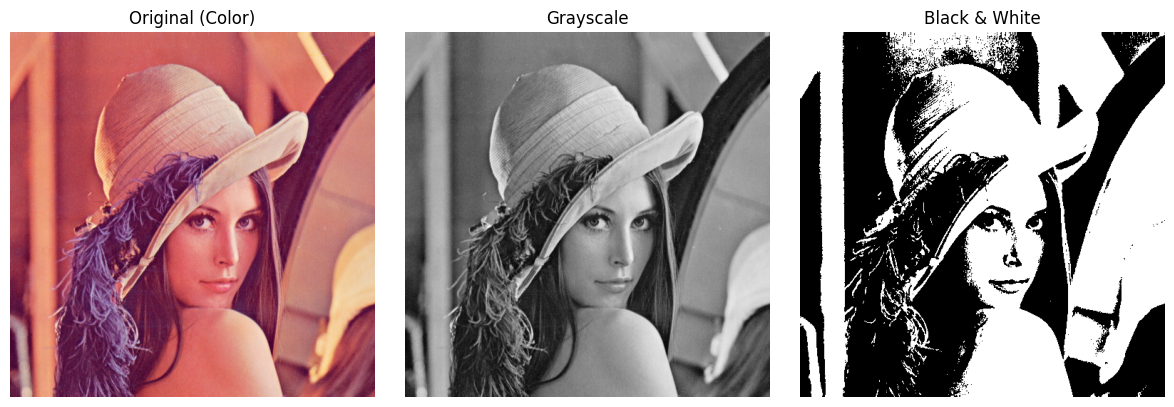

In [14]:
#Task 2.3 converting coloured image to grayscale
import cv2
import numpy as np
import urllib.request

# 1. Direct web link to an online image
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"

# 2. Fetch the image from the web as a byte stream
req = urllib.request.urlopen(url)
image_bytes = bytearray(req.read())
image_array = np.asarray(image_bytes, dtype=np.uint8)

# 3. Decode the byte array into an OpenCV BGR image
color_img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# 4. Convert to Grayscale
gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)

# 5. Convert Grayscale to Black & White (Binary)
_, bw_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)

# 6. Save the results locally
cv2.imwrite('grayscale.jpg', gray_img)
cv2.imwrite('black_and_white.jpg', bw_img)
print("Processing complete! Saved 'grayscale.jpg' and 'black_and_white.jpg'.")

import cv2
import matplotlib.pyplot as plt

# 1. Convert original OpenCV image from BGR to RGB for Matplotlib
color_img_rgb = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)

# 2. Set up the display grid (1 row, 3 columns)
plt.figure(figsize=(12, 4))

# Original Color Image
plt.subplot(1, 3, 1)
plt.imshow(color_img_rgb)
plt.title('Original (Color)')
plt.axis('off')

# Grayscale Image
plt.subplot(1, 3, 2)
plt.imshow(gray_img, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

# Black & White (Binary) Image
plt.subplot(1, 3, 3)
plt.imshow(bw_img, cmap='gray')
plt.title('Black & White')
plt.axis('off')

# Render the plots inline
plt.tight_layout()
plt.show()

Original image:


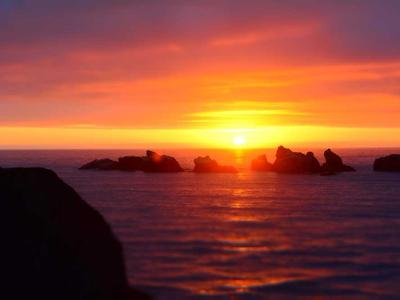

Horizontally reversed:


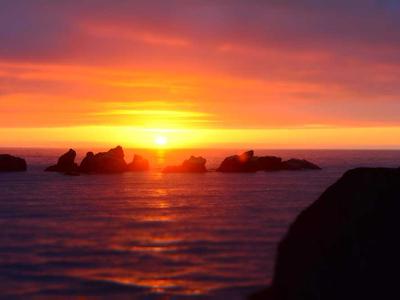

Vertically reversed:


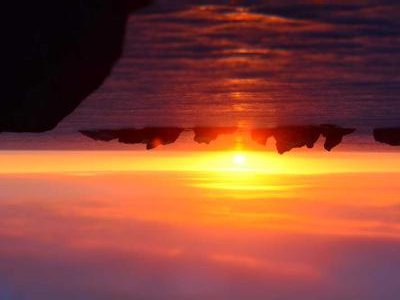

In [15]:
#TASK 2.4 - Horizontally and vertically reverse the images


import cv2
from google.colab.patches import cv2_imshow

# Download a photograph
!wget -q -O photo.jpg "https://picsum.photos/400/300"

# Read the photograph
img = cv2.imread("photo.jpg")

if img is None:
    print("Could not load the image. Try downloading it again.")
else:
    # 1 = horizontal flip; 0 = vertical flip
    horizontal_image = cv2.flip(img, 1)
    vertical_image = cv2.flip(img, 0)

    print("Original image:")
    cv2_imshow(img)

    print("Horizontally reversed:")
    cv2_imshow(horizontal_image)

    print("Vertically reversed:")
    cv2_imshow(vertical_image)

    # Save the results
    cv2.imwrite("horizontal_flip.jpg", horizontal_image)
    cv2.imwrite("vertical_flip.jpg", vertical_image)

Top-left portion:


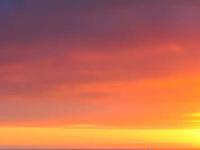

Bottom-right portion:


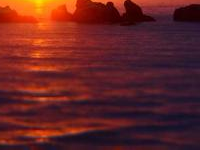

Center portion:


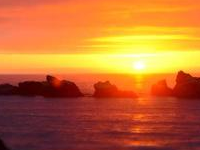

In [16]:

# Task 2.5: Crop different portions of an image

import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("photo.jpg")

if img is None:
    print("Could not load photo.jpg. Run Task 2.4 first.")
else:
    height, width = img.shape[:2]

    # Crop different portions
    top_left = img[:height // 2, :width // 2]
    bottom_right = img[height // 2:, width // 2:]
    center = img[height // 4:3 * height // 4,
                 width // 4:3 * width // 4]

    print("Top-left portion:")
    cv2_imshow(top_left)

    print("Bottom-right portion:")
    cv2_imshow(bottom_right)

    print("Center portion:")
    cv2_imshow(center)

    # Save the cropped images
    cv2.imwrite("crop_top_left.jpg", top_left)
    cv2.imwrite("crop_bottom_right.jpg", bottom_right)
    cv2.imwrite("crop_center.jpg", center)

Original image:


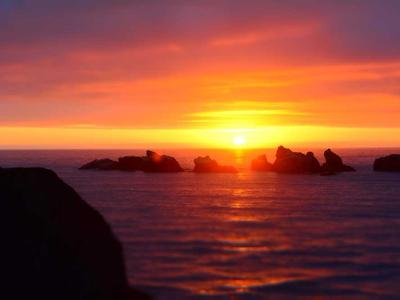

Negative image:


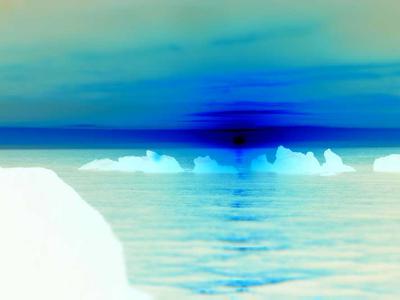

In [17]:
# Task 2.6: Find the negative of an image

import cv2
from google.colab.patches import cv2_imshow

# Load the photograph from Task 2.4
img = cv2.imread("photo.jpg")

if img is None:
    print("Could not load photo.jpg. Run Task 2.4 first.")
else:
    # Invert every color channel
    negative_image = 255 - img

    print("Original image:")
    cv2_imshow(img)

    print("Negative image:")
    cv2_imshow(negative_image)

    # Save the negative image
    cv2.imwrite("negative_image.jpg", negative_image)

Original grayscale image:


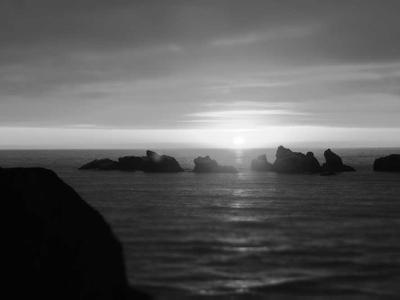

Negative grayscale image:


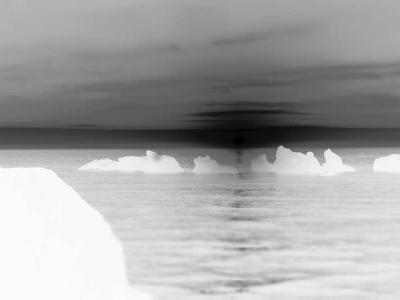

In [18]:
# Task 2.6: Negative of a grayscale (black-and-white) image

import cv2
from google.colab.patches import cv2_imshow

# Load the photograph directly in grayscale
gray_img = cv2.imread("photo.jpg", cv2.IMREAD_GRAYSCALE)

if gray_img is None:
    print("Could not load photo.jpg. Run Task 2.4 first.")
else:
    # Calculate the negative
    negative_gray = 255 - gray_img

    print("Original grayscale image:")
    cv2_imshow(gray_img)

    print("Negative grayscale image:")
    cv2_imshow(negative_gray)

    # Save the result
    cv2.imwrite("negative_grayscale.jpg", negative_gray)